In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Setup

Results taken from [s3://ai2-llm/evaluation/microanneal-peteish-7b-postmortem/](https://us-east-1.console.aws.amazon.com/s3/buckets/ai2-llm?region=us-east-1&bucketType=general&prefix=evaluation/microanneal-peteish-7b-postmortem/&showversions=false).

Results reported in OLMo 2 paper in [Section 4.2.2](https://arxiv.org/pdf/2501.00656#page=23.22), with the final mixture reported in [Table 2](https://arxiv.org/pdf/2501.00656#page=4.96).

For the exact composition of each data mix: See [this Google Sheet](https://docs.google.com/spreadsheets/d/1nE5LsmVaU8yxjOFTFJuqA_pfE14etRLubnJuoRZbITA/edit?gid=829557504#gid=829557504).

In [34]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [35]:
pull_predictions_from_weka("olmo2_anneals")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_olmo2_anneals_predictions.parquet


In [36]:
# load a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'native_id']
COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice', 'logits_per_char_corr', 'logits_per_byte_corr'] # accuracy benchmarks
COLS += ['exact_match', 'f1'] # generation benchmarks

df = pd.read_parquet(f'{DATA_DIR}/all_olmo2_anneals_predictions.parquet', columns=COLS)

# Set the 'mix' column to the value of the 'model' column
df = df.reset_index()
df['mix'] = df['model']
df = df.set_index(['task', 'model', 'step', 'mix'])

print(f'Loaded {len(df):,} instance predictions')

Loaded 2,829,024 instance predictions


In [37]:
MODELS = df.index.get_level_values('model').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()

In [38]:
# Exclude some models
EXCLUDED_MODELS = []

In [46]:
print(TASKS)

['arc_challenge:mc', 'mmlu_econometrics:mc', 'mmlu_high_school_psychology:mc', 'openbookqa', 'mmlu_electrical_engineering:mc', 'winogrande', 'mmlu_us_foreign_policy:mc', 'mmlu_public_relations:mc', 'mmlu_college_medicine:mc', 'mmlu_business_ethics:mc', 'mmlu_high_school_chemistry:mc', 'mmlu_clinical_knowledge:mc', 'mmlu_professional_accounting:mc', 'mmlu_computer_security:mc', 'mmlu_college_physics:mc', 'mmlu_high_school_world_history:mc', 'mmlu_nutrition:mc', 'boolq', 'mmlu_medical_genetics:mc', 'mmlu_high_school_biology:mc', 'gsm8k', 'mmlu_logical_fallacies:mc', 'newsqa', 'mmlu_college_mathematics:mc', 'hellaswag', 'mmlu_jurisprudence:mc', 'mmlu_conceptual_physics:mc', 'mmlu_high_school_macroeconomics:mc', 'mmlu_miscellaneous:mc', 'mmlu_virology:mc', 'mmlu_high_school_government_and_politics:mc', 'mmlu_high_school_us_history:mc', 'mmlu_professional_psychology:mc', 'mmlu_elementary_mathematics:mc', 'mmlu_global_facts:mc', 'mmlu_security_studies:mc', 'mmlu_philosophy:mc', 'mmlu_high_sc

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]


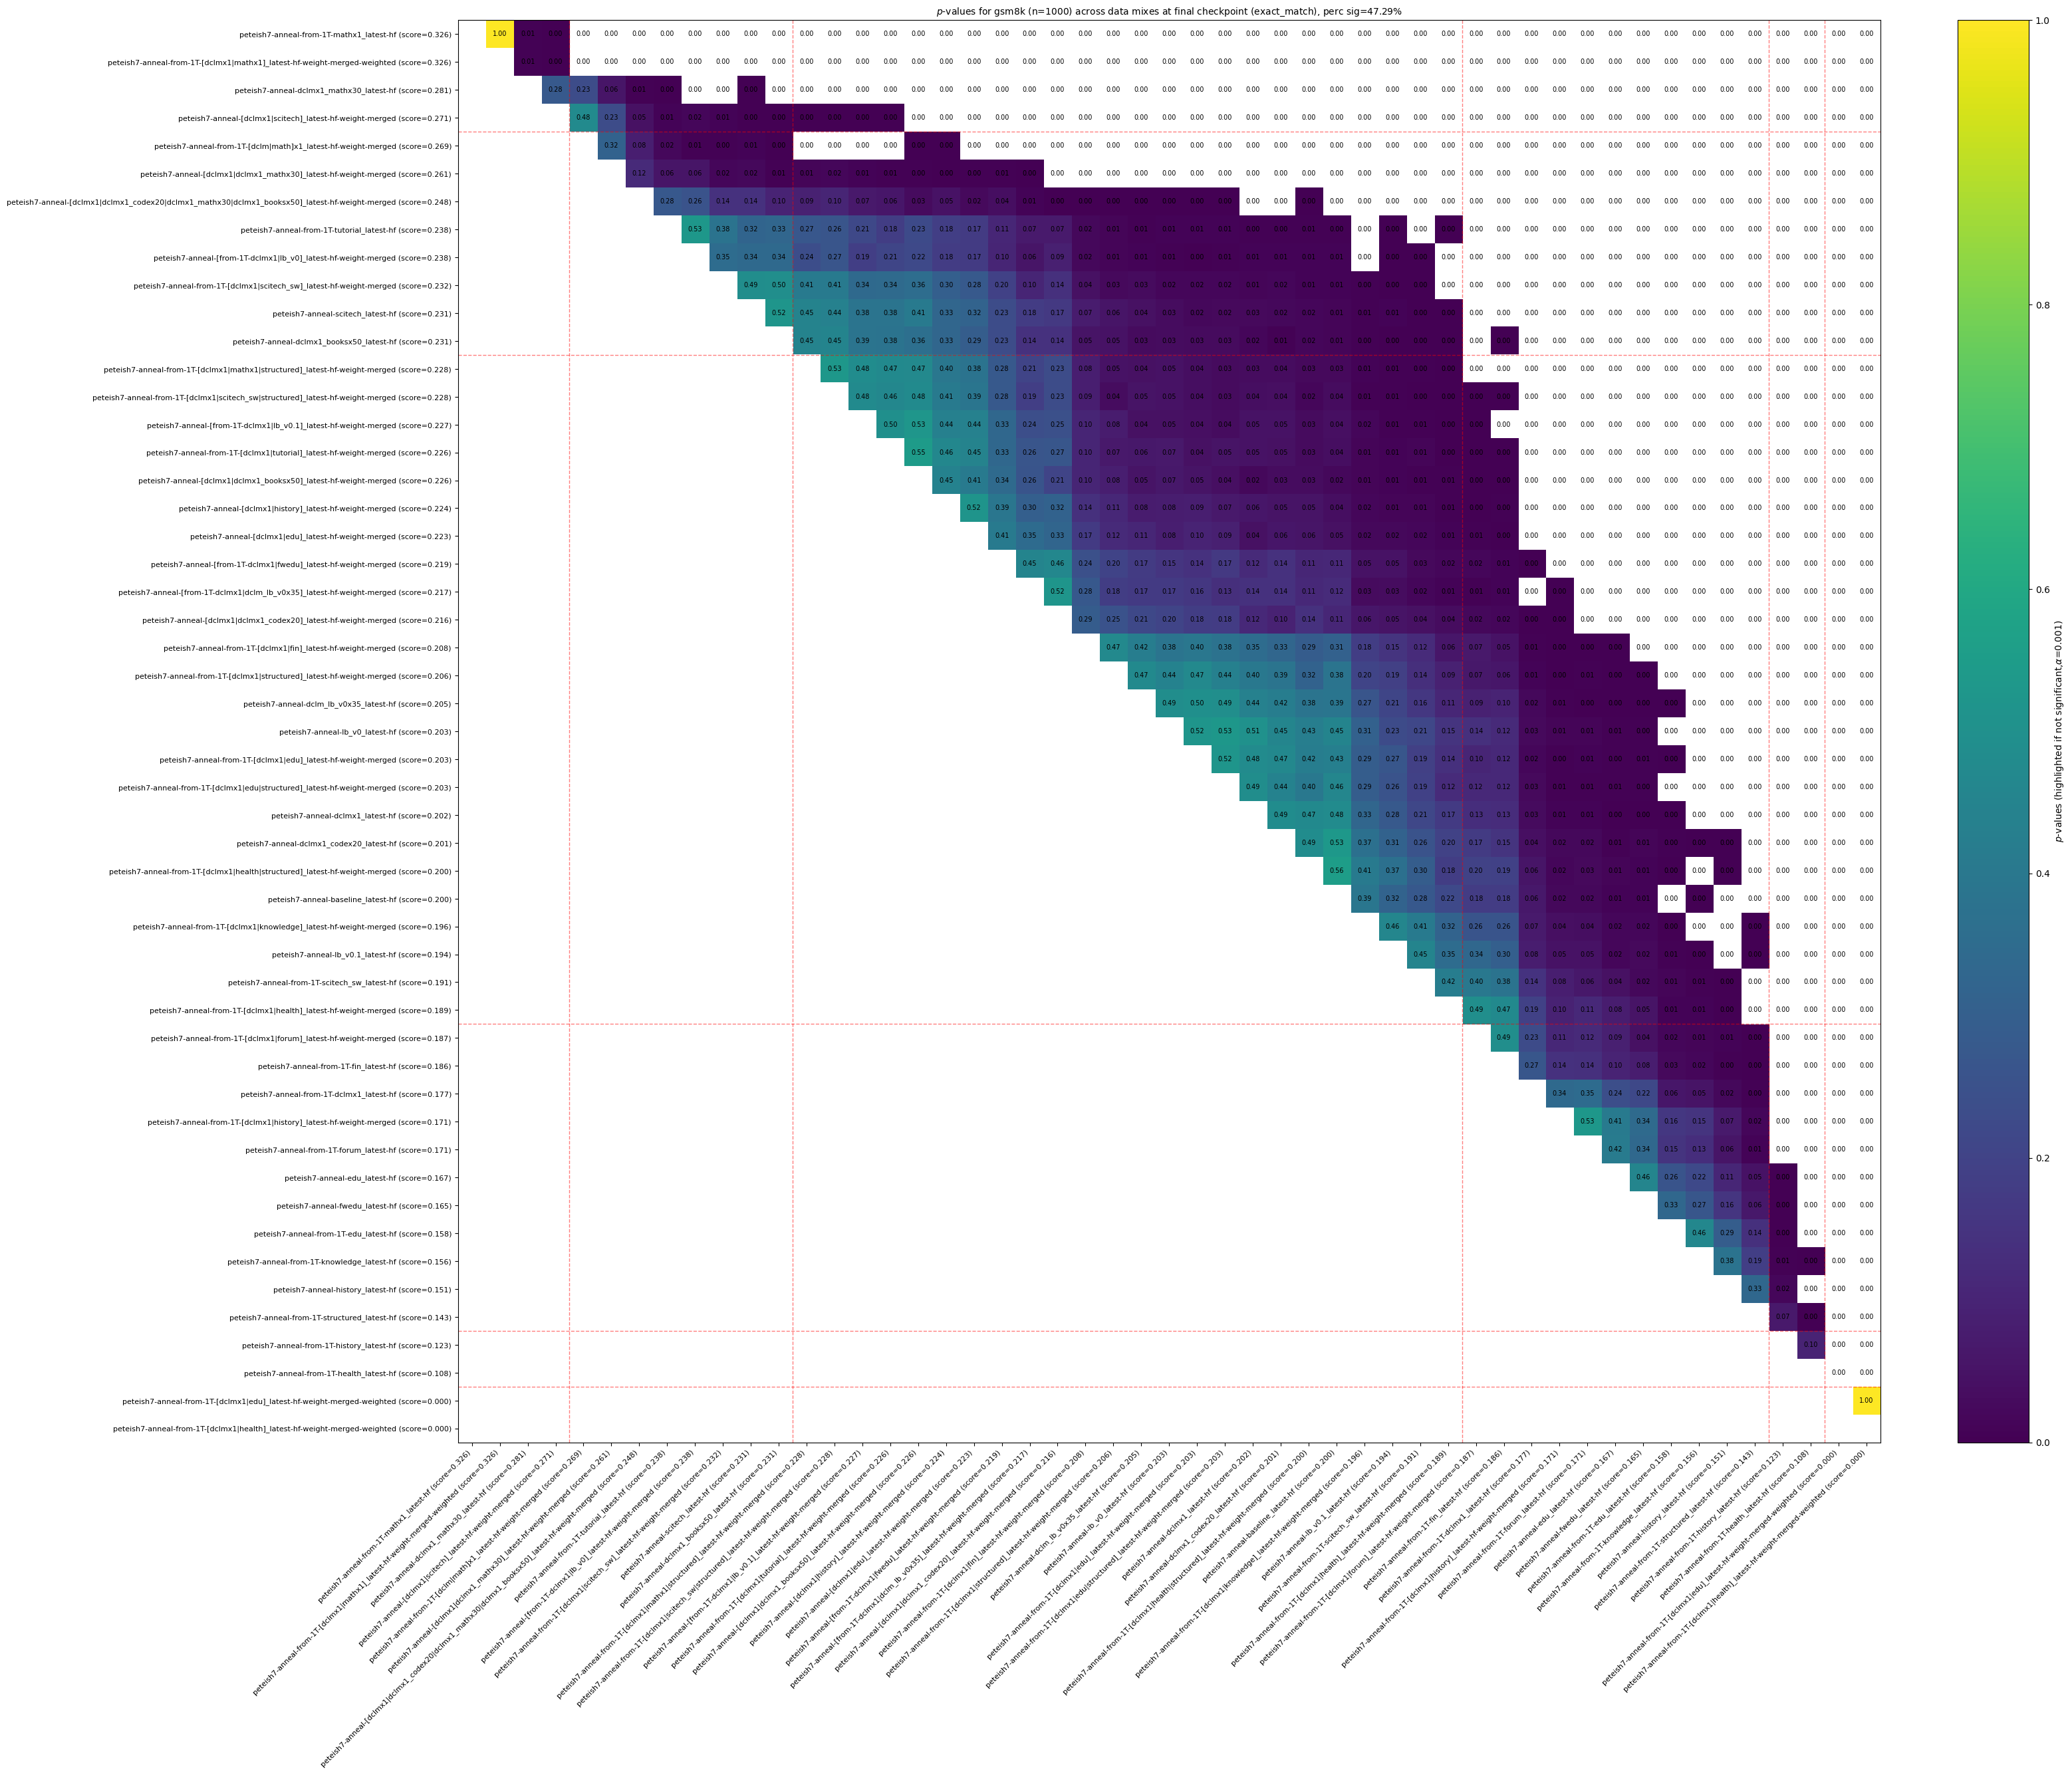

In [50]:
from stats import compute_significance

models = list(set(MODELS) - set(EXCLUDED_MODELS))
tasks  = TASKS

_, p_values, _ = compute_significance(
    df, 
    models=models, 
    metric='exact_match',
    # metric='acc_per_char',
    step=None,     # the models have different checkpoint steps
    last_n=1,      # the "last n" checkpoints to average results
    alpha=0.001,   # significance level
    # tasks=tasks, # single tasks (e.g., hellaswag) or suites (e.g., OLMES)
    tasks=['gsm8k'],
    # tasks=['arc_easy'],
    do_plot=True
)